# Wavefront aberration diagnostic for coherent LiDAR

A standalone toolkit that takes any optical pipeline (built from Gaussian Beam Decomposition primitives), computes the standard wavefront-aberration metrics that real LiDAR optics engineers use, and decomposes the wavefront error into named Zernike modes.

## Purpose

For an on-axis Gaussian beam (`x = 0`, `kx = 0`), measure standard wavefront metrics after each optical element in a representative coherent LiDAR pipeline. The same set of metrics appears on every coherent FMCW LiDAR datasheet and in every optical-shop test report.

Metrics computed at the diagnostic plane:

- **OPD (optical path difference)** — `arg(E_actual) − arg(E_ideal)`, in waves
- **RMS wavefront error** — RMS of OPD over a circular aperture, in waves. Maréchal criterion: < λ/14 RMS = diffraction-limited
- **PV (peak-to-valley)** — max minus min of OPD over the aperture
- **Strehl ratio** — extended Maréchal: `S ≈ exp(−(2π·σ_RMS)²)`. Strehl > 0.8 = diffraction-limited
- **Heterodyne efficiency η** — `|∫E·E_LO* dA|² / (∫|E|²·∫|E_LO|²)`. THE figure of merit for coherent LiDAR (directly multiplies SNR)
- **Zernike decomposition** — first 15 Noll-indexed modes. Names the aberration (defocus, coma, astigmatism, spherical, …)

## The design-vs-disturbance principle

Wavefront error is the deviation of the actual wavefront from an *ideal reference* wavefront. The reference must include all **designed-in elements** (lens, scanner, mirror — these are supposed to shape the wavefront) but exclude all **disturbances** (atmospheric turbulence, manufacturing defects, misalignment — these are unwanted).

Concretely: `E_ideal` = analytic single-Gaussian propagated through the same designed elements as `E_actual`, but with no disturbances. The difference is the aberration.

This is exactly how real optical interferometers (Zygo, 4D Technology) work: they compare your real lens against the *intended* spherical wavefront for that design — not against a flat reference. The same convention is used here.

## Configurations

| Config | Elements | Expectation |
|---|---|---|
| C0 | Source + free space | Baseline beam-decomposition propagation |
| C1 | + thin lens (f = 1 m) | Designed lens block |
| C2 | + scanner (θ = 0) | Identical to C1 (scanner is transparent at zero tilt) |
| C3 | + planar mirror (z = R, image method) | Identical to C1 (mirror is transparent in q-space) |
| C4 (demo) | C1 + injected 0.1λ-RMS phase aberration | Verifies the diagnostic actually fires when something is wrong |

Configs C0–C3 are an *unaberrated* pipeline; they should report near-zero RMS, Strehl ≈ 1, η ≈ 1. C4 injects a known aberration to validate the diagnostic and to preview the kind of numbers that real-world disturbances (atmosphere, lens defects) will produce.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Optical parameters
wavelength = 1550e-9
k = 2 * np.pi / wavelength
w0_source = 1.0e-3
zR_source = np.pi * w0_source**2 / wavelength
f_lens = 1.0
R_target = 100.0
z_diag = 100.0          # diagnostic plane for configs without mirror
aperture_radius = 0.10  # 100 mm circular aperture for analysis

# Source basis: 9×9 = 81 beamlets at z=0, w=1mm each, 1.5mm spacing
n_per_axis = 9
spacing_source = 1.5e-3
w_basis_source = 1.0e-3
x0_grid_source = (np.arange(n_per_axis) - (n_per_axis - 1) / 2) * spacing_source
lambda_reg = 1e-8

# LSQ grid (for source decomposition)
Nx_lsq, Lx_lsq = 401, 20e-3
x_lsq = np.linspace(-Lx_lsq, Lx_lsq, Nx_lsq)
y_lsq = np.linspace(-Lx_lsq, Lx_lsq, Nx_lsq)
X_lsq, Y_lsq = np.meshgrid(x_lsq, y_lsq, indexing='xy')

# Diagnostic grid (wide enough to hold all post-lens beamlets at z=2R)
Nx_d, Lx_d = 401, 1500e-3
x_d = np.linspace(-Lx_d, Lx_d, Nx_d)
y_d = np.linspace(-Lx_d, Lx_d, Nx_d)
X_d, Y_d = np.meshgrid(x_d, y_d, indexing='xy')
dx_d = x_d[1] - x_d[0]

print(f'Grids: LSQ {Nx_lsq}^2 (±{Lx_lsq*1e3:.0f}mm), diag {Nx_d}^2 (±{Lx_d*1e3:.0f}mm, dx={dx_d*1e3:.1f}mm)')
print(f'Aperture for analysis: radius = {aperture_radius*1e3:.0f} mm')


Grids: LSQ 401^2 (±20mm), diag 401^2 (±1500mm, dx=7.5mm)
Aperture for analysis: radius = 100 mm


## Beam-propagation primitives

State-tracking q-parameter formalism: each Gaussian beamlet is described by a complex state carrying `(q_anchor, position, tilt)`. Free space, lens, and scanner all act as closed-form transformations on this state. The full beam is reconstructed by summing the basis at any output plane.


In [2]:
def make_state(w0, k, x0=0.0, y0=0.0, kx=0.0, ky=0.0, z0=0.0):
    wl = 2 * np.pi / k
    zR = np.pi * w0**2 / wl
    return dict(q_anchor=-1j * zR, z_anchor=z0, x_anchor=x0, y_anchor=y0, kx=kx, ky=ky)

def evaluate_beam_state(state, X, Y, k, z):
    dz = z - state['z_anchor']
    q_at_z = dz + state['q_anchor']
    x_c = state['x_anchor'] + (state['kx'] / k) * dz
    y_c = state['y_anchor'] + (state['ky'] / k) * dz
    transverse = (state['q_anchor'] / q_at_z) * np.exp(1j * k * ((X - x_c)**2 + (Y - y_c)**2) / (2 * q_at_z))
    kz = np.sqrt(k**2 - state['kx']**2 - state['ky']**2)
    return transverse * np.exp(1j * kz * dz) * np.exp(1j * (state['kx'] * X + state['ky'] * Y))

def apply_thin_lens(state, f, z_lens, k):
    dz = z_lens - state['z_anchor']
    q_at_lens = dz + state['q_anchor']
    x_at_lens = state['x_anchor'] + (state['kx'] / k) * dz
    y_at_lens = state['y_anchor'] + (state['ky'] / k) * dz
    return dict(q_anchor=1.0 / (1.0 / q_at_lens - 1.0 / f), z_anchor=z_lens,
                x_anchor=x_at_lens, y_anchor=y_at_lens,
                kx=state['kx'] - k * x_at_lens / f, ky=state['ky'] - k * y_at_lens / f)

def apply_scanner(state, theta_x, theta_y, k):
    new = dict(state)
    new['kx'] = state['kx'] + k * np.sin(theta_x)
    new['ky'] = state['ky'] + k * np.sin(theta_y)
    return new

def basis_sum_at_z(states, c, X, Y, k, z):
    E = np.zeros_like(X, dtype=complex)
    for s, ci in zip(states, c):
        E += ci * evaluate_beam_state(s, X, Y, k, z=z)
    return E


## Zernike basis & wavefront analysis

The first 15 Noll-indexed Zernike modes over a unit disk, plus a single function that returns RMS, PV, Strehl, η, and a Zernike fit given a complex GBD field and an ideal reference field.

The OPD is computed as `arg(E_GBD · conj(E_ideal))`, which equals `arg(E_GBD) - arg(E_ideal)` modulo 2π — safer numerically because it avoids the explicit phase-difference wrap.


In [3]:
def zernike_basis(rho, theta, n_modes=15):
    """Noll-indexed Zernike modes over the unit disk."""
    Z = []
    Z.append(np.ones_like(rho))                                            # 1 piston
    Z.append(2 * rho * np.cos(theta))                                      # 2 tilt x
    Z.append(2 * rho * np.sin(theta))                                      # 3 tilt y
    Z.append(np.sqrt(3) * (2 * rho**2 - 1))                                # 4 defocus
    Z.append(np.sqrt(6) * rho**2 * np.sin(2 * theta))                      # 5 astig 45
    Z.append(np.sqrt(6) * rho**2 * np.cos(2 * theta))                      # 6 astig 0
    Z.append(np.sqrt(8) * (3 * rho**3 - 2 * rho) * np.sin(theta))          # 7 coma y
    Z.append(np.sqrt(8) * (3 * rho**3 - 2 * rho) * np.cos(theta))          # 8 coma x
    Z.append(np.sqrt(8) * rho**3 * np.sin(3 * theta))                      # 9 trefoil y
    Z.append(np.sqrt(8) * rho**3 * np.cos(3 * theta))                      # 10 trefoil x
    Z.append(np.sqrt(5) * (6 * rho**4 - 6 * rho**2 + 1))                   # 11 spherical
    Z.append(np.sqrt(10) * (4 * rho**4 - 3 * rho**2) * np.sin(2 * theta))  # 12 sec astig 45
    Z.append(np.sqrt(10) * (4 * rho**4 - 3 * rho**2) * np.cos(2 * theta))  # 13 sec astig 0
    Z.append(np.sqrt(10) * rho**4 * np.sin(4 * theta))                     # 14 quadrafoil 45
    Z.append(np.sqrt(10) * rho**4 * np.cos(4 * theta))                     # 15 quadrafoil 0
    return Z[:n_modes]

ZERNIKE_NAMES = [
    'Z1 piston', 'Z2 tilt x', 'Z3 tilt y', 'Z4 defocus',
    'Z5 astig 45', 'Z6 astig 0', 'Z7 coma y', 'Z8 coma x',
    'Z9 trefoil y', 'Z10 trefoil x', 'Z11 spherical',
    'Z12 sec astig 45', 'Z13 sec astig 0', 'Z14 quadrafoil 45', 'Z15 quadrafoil 0',
]

def wavefront_analysis(E_field, E_ideal, X, Y, ap_radius):
    """Compute RMS, PV, Strehl, η, Zernikes over a circular aperture."""
    opd_rad_full = np.angle(E_field * np.conj(E_ideal))
    rho_phys = np.sqrt(X**2 + Y**2)
    mask = rho_phys <= ap_radius

    opd_in = opd_rad_full[mask].copy()
    opd_in -= opd_in.mean()  # subtract piston (handles global offset)

    rho_norm = (rho_phys / ap_radius)[mask]
    theta = np.arctan2(Y, X)[mask]
    Z_basis = zernike_basis(rho_norm, theta, n_modes=15)
    Z_matrix = np.array(Z_basis).T
    coeffs, *_ = np.linalg.lstsq(Z_matrix, opd_in, rcond=None)

    opd_waves_in = opd_in / (2 * np.pi)
    rms_waves = float(np.sqrt(np.mean(opd_waves_in**2)))
    pv_waves = float(opd_waves_in.max() - opd_waves_in.min())
    strehl = float(np.exp(-(2 * np.pi * rms_waves)**2))

    Esig, Eref = E_field[mask], E_ideal[mask]
    eta = float(np.abs(np.sum(Esig * np.conj(Eref)))**2 /
                (np.sum(np.abs(Esig)**2) * np.sum(np.abs(Eref)**2)))

    opd_full = np.where(mask, (opd_rad_full - opd_rad_full[mask].mean()) / (2 * np.pi), np.nan)
    return dict(rms_waves=rms_waves, pv_waves=pv_waves, strehl=strehl, eta=eta,
                zernike_coeffs=coeffs, opd_waves=opd_full, mask=mask)


## Build basis & decompose source

9×9 = 81 beamlets at z = 0. Tikhonov-regularized least-squares projects the source Gaussian onto the basis, returning a vector of complex coefficients. The residual on the LSQ grid is the basis-decomposition floor — typically 10⁻¹⁰ relative error.


In [4]:
t0 = time.time()
basis_source = [make_state(w_basis_source, k, x0=x0i, y0=y0i, z0=0.0)
                for x0i in x0_grid_source for y0i in x0_grid_source]
N_beams = len(basis_source)
G = np.zeros((Nx_lsq * Nx_lsq, N_beams), dtype=complex)
for i, s in enumerate(basis_source):
    G[:, i] = evaluate_beam_state(s, X_lsq, Y_lsq, k, z=0.0).ravel()
E_src = np.exp(-(X_lsq**2 + Y_lsq**2) / w0_source**2).astype(complex)
A = G.conj().T @ G + lambda_reg * np.eye(N_beams)
b = G.conj().T @ E_src.ravel()
c_source = np.linalg.solve(A, b)
L2 = np.linalg.norm((G @ c_source).reshape(Nx_lsq, Nx_lsq) - E_src) / np.linalg.norm(E_src)
del G
print(f'Basis: {N_beams} beamlets   Source-decomp residual: {L2:.3e}   ({time.time()-t0:.1f}s)')


Basis: 81 beamlets   Source-decomp residual: 8.268e-11   (1.2s)


## Run Configurations C0–C3

For each config, propagate the basis through the prescribed elements, evaluate the GBD field on the diagnostic grid, build the corresponding *ideal* analytic field (single Gaussian through same elements), and compare.

In [5]:
def ideal_field_at(z_eval, has_lens, k, w0, X, Y):
    """Single analytic Gaussian, optionally through lens at z=0, evaluated at z_eval."""
    state = make_state(w0, k)
    if has_lens:
        state = apply_thin_lens(state, f_lens, 0.0, k)
    return evaluate_beam_state(state, X, Y, k, z=z_eval)

configs = [
    dict(name='C0 free space',          has_lens=False, has_scanner=False, has_mirror=False),
    dict(name='C1 + thin lens',         has_lens=True,  has_scanner=False, has_mirror=False),
    dict(name='C2 + scanner (θ=0)',     has_lens=True,  has_scanner=True,  has_mirror=False),
    dict(name='C3 + planar mirror',     has_lens=True,  has_scanner=True,  has_mirror=True),
]

results = []
for cfg in configs:
    states = list(basis_source)
    if cfg['has_lens']:
        states = [apply_thin_lens(s, f_lens, 0.0, k) for s in states]
    if cfg['has_scanner']:
        states = [apply_scanner(s, 0.0, 0.0, k) for s in states]
    z_eval = 2 * R_target if cfg['has_mirror'] else z_diag

    t1 = time.time()
    E_gbd = basis_sum_at_z(states, c_source, X_d, Y_d, k, z=z_eval)
    E_ref = ideal_field_at(z_eval, cfg['has_lens'], k, w0_source, X_d, Y_d)
    metrics = wavefront_analysis(E_gbd, E_ref, X_d, Y_d, aperture_radius)
    metrics['config'] = cfg['name']
    metrics['z_eval'] = z_eval
    results.append(metrics)
    print(f"{cfg['name']:30s} z={z_eval:5.0f}m   "
          f"RMS={metrics['rms_waves']*1000:8.3e} mλ   "
          f"Strehl={metrics['strehl']:.6f}   "
          f"η={metrics['eta']:.6f}   ({time.time()-t1:.1f}s)")


C0 free space                  z=  100m   RMS=1.898e-09 mλ   Strehl=1.000000   η=1.000000   (1.1s)


C1 + thin lens                 z=  100m   RMS=2.500e-09 mλ   Strehl=1.000000   η=1.000000   (1.1s)


C2 + scanner (θ=0)             z=  100m   RMS=2.500e-09 mλ   Strehl=1.000000   η=1.000000   (1.3s)


C3 + planar mirror             z=  200m   RMS=5.191e-10 mλ   Strehl=1.000000   η=1.000000   (1.2s)


## Sanity check — C1, C2, C3 should be identical

Scanner at θ=0 adds nothing (kx=ky=0). Planar mirror via image method is transparent in q-space (only adds propagation distance, which is matched in the ideal reference). So if our framework is consistent, the three configs should produce bit-identical metrics.

In [6]:
print('Cross-config sanity (max |Δ| across C1/C2/C3):')
for key in ['rms_waves', 'pv_waves', 'strehl', 'eta']:
    vals = [r[key] for r in results[1:]]
    delta = max(abs(vals[1] - vals[0]), abs(vals[2] - vals[0]))
    print(f'   {key:12s}: C1={vals[0]:.6e}  C2={vals[1]:.6e}  C3={vals[2]:.6e}  max|Δ|={delta:.3e}')


Cross-config sanity (max |Δ| across C1/C2/C3):
   rms_waves   : C1=2.500091e-12  C2=2.500091e-12  C3=5.190794e-13  max|Δ|=1.981e-12
   pv_waves    : C1=8.430923e-12  C2=8.430923e-12  C3=1.781061e-12  max|Δ|=6.650e-12
   strehl      : C1=1.000000e+00  C2=1.000000e+00  C3=1.000000e+00  max|Δ|=0.000e+00
   eta         : C1=1.000000e+00  C2=1.000000e+00  C3=1.000000e+00  max|Δ|=0.000e+00


## OPD maps (C0–C3)

2-D color maps of the wavefront error in milliwaves. For an unaberrated pipeline these maps will look essentially flat (basis floor only).

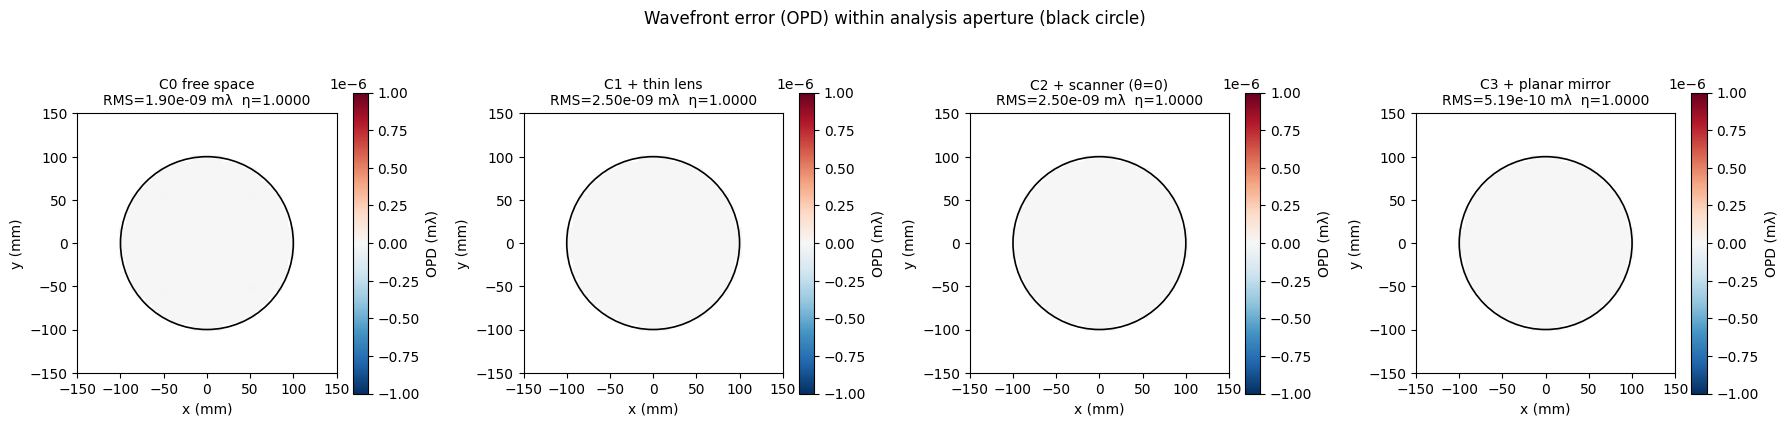

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
vmax_global = max(np.nanmax(np.abs(r['opd_waves'])) for r in results) * 1000  # mλ
vmax_global = max(vmax_global, 1e-6)  # avoid zero range
for ax, r in zip(axes, results):
    im = ax.imshow(r['opd_waves'] * 1000,
                   extent=[-Lx_d*1e3, Lx_d*1e3, -Lx_d*1e3, Lx_d*1e3],
                   cmap='RdBu_r', vmin=-vmax_global, vmax=+vmax_global, origin='lower')
    circ = plt.Circle((0, 0), aperture_radius*1e3, fill=False, edgecolor='k', linewidth=1.2)
    ax.add_patch(circ)
    ax.set_xlim(-150, 150); ax.set_ylim(-150, 150)
    ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
    ax.set_title(f"{r['config']}\nRMS={r['rms_waves']*1000:.2e} mλ  η={r['eta']:.4f}", fontsize=10)
    plt.colorbar(im, ax=ax, label='OPD (mλ)', shrink=0.85)
fig.suptitle('Wavefront error (OPD) within analysis aperture (black circle)', y=1.02)
plt.tight_layout(); plt.show()


## Zernike bar charts (C0–C3)

Coefficients in milliwaves. Real aberrations would show large bars on physically-meaningful modes (defocus, coma, spherical, …). For our unaberrated pipeline, every bar should be at noise floor.

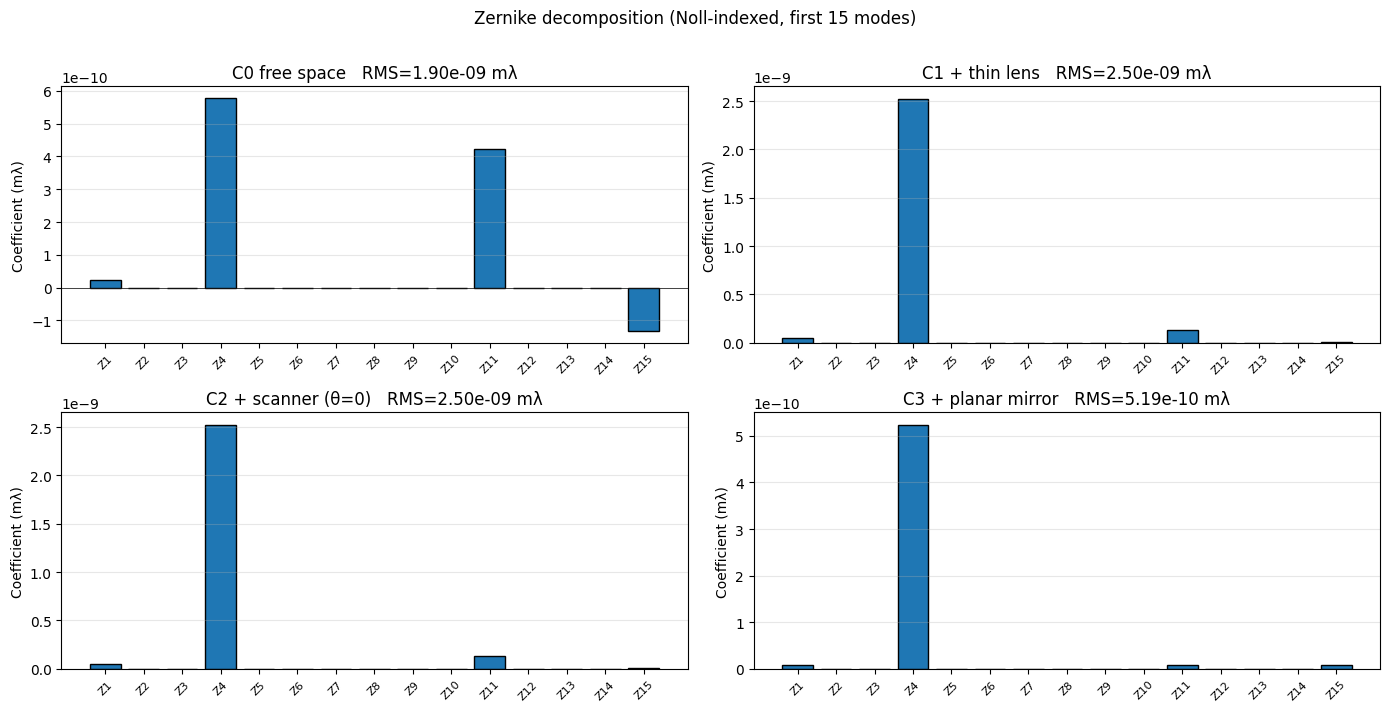

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
axes = axes.flatten()
for ax, r in zip(axes, results):
    coeffs_mwaves = r['zernike_coeffs'] / (2 * np.pi) * 1000  # mλ
    ax.bar(range(1, 16), coeffs_mwaves, edgecolor='k')
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_xticks(range(1, 16))
    ax.set_xticklabels([n.split()[0] for n in ZERNIKE_NAMES], rotation=45, fontsize=8)
    ax.set_ylabel('Coefficient (mλ)')
    ax.set_title(f"{r['config']}   RMS={r['rms_waves']*1000:.2e} mλ")
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Zernike decomposition (Noll-indexed, first 15 modes)', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()


## C4 demo — inject a known aberration

To verify the diagnostic actually fires when there's something to measure, take Config C1 and apply a phase screen with a known mix of Zernike modes:

- **+0.10 λ** of defocus (Z4)
- **+0.05 λ** of coma_x (Z8)
- **+0.04 λ** of spherical (Z11)

Recovered Zernike coefficients should match exactly. RMS should be ≈ √(0.10² + 0.05² + 0.04²) = 0.118 λ. This magnitude of wavefront error is representative of what moderate atmospheric turbulence produces over a 100 m horizontal path at automotive ground level.


In [9]:
states = [apply_thin_lens(s, f_lens, 0.0, k) for s in basis_source]
z_eval = z_diag
E_gbd_C1 = basis_sum_at_z(states, c_source, X_d, Y_d, k, z=z_eval)
E_ref_C1 = ideal_field_at(z_eval, True, k, w0_source, X_d, Y_d)

rho_phys = np.sqrt(X_d**2 + Y_d**2)
rho_norm = np.minimum(rho_phys / aperture_radius, 1.0)
theta_full = np.arctan2(Y_d, X_d)
aber_waves = (0.10 * np.sqrt(3) * (2 * rho_norm**2 - 1)
              + 0.05 * np.sqrt(8) * (3 * rho_norm**3 - 2 * rho_norm) * np.cos(theta_full)
              + 0.04 * np.sqrt(5) * (6 * rho_norm**4 - 6 * rho_norm**2 + 1))
phase_screen = np.exp(1j * 2 * np.pi * aber_waves)
E_aberrated = E_gbd_C1 * phase_screen
metrics_C4 = wavefront_analysis(E_aberrated, E_ref_C1, X_d, Y_d, aperture_radius)
metrics_C4['config'] = 'C4 DEMO (injected 0.1λ aber)'
metrics_C4['z_eval'] = z_eval

print(f"   RMS  = {metrics_C4['rms_waves']*1000:8.3f} mλ  ({metrics_C4['rms_waves']*wavelength*1e9:6.1f} nm)")
print(f"   PV   = {metrics_C4['pv_waves']*1000:8.3f} mλ  ({metrics_C4['pv_waves']*wavelength*1e9:6.1f} nm)")
print(f"   Strehl     = {metrics_C4['strehl']:.4f}")
print(f"   η (hetero) = {metrics_C4['eta']:.4f}")
print('   Top-5 recovered Zernike modes (mλ):')
sorted_idx = np.argsort(np.abs(metrics_C4['zernike_coeffs']))[::-1]
for i in sorted_idx[:5]:
    print(f"      {ZERNIKE_NAMES[i]:25s} = {metrics_C4['zernike_coeffs'][i]/(2*np.pi)*1000:+9.4f}")
print(f'\n   Expected: defocus≈+100, coma_x≈+50, spherical≈+40 (mλ)')


   RMS  =  115.979 mλ  ( 179.8 nm)
   PV   =  554.971 mλ  ( 860.2 nm)
   Strehl     = 0.5880
   η (hetero) = 0.7009
   Top-5 recovered Zernike modes (mλ):
      Z4 defocus                = +100.0000
      Z8 coma x                 =  +50.0000
      Z11 spherical             =  +40.0000
      Z1 piston                 =   +2.6011
      Z15 quadrafoil 0          =   +0.0000

   Expected: defocus≈+100, coma_x≈+50, spherical≈+40 (mλ)


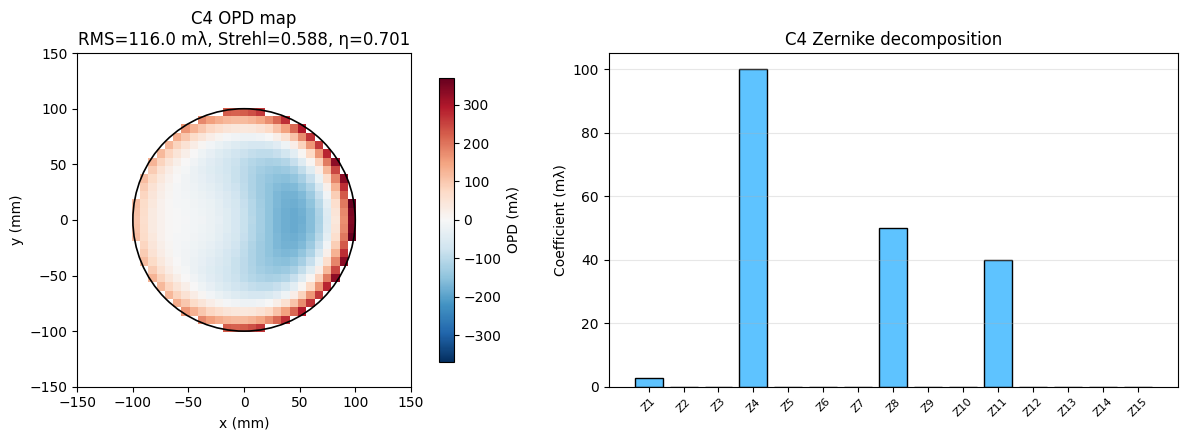

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
vmax = np.nanmax(np.abs(metrics_C4['opd_waves'])) * 1000
im = axes[0].imshow(metrics_C4['opd_waves'] * 1000,
                    extent=[-Lx_d*1e3, Lx_d*1e3, -Lx_d*1e3, Lx_d*1e3],
                    cmap='RdBu_r', vmin=-vmax, vmax=+vmax, origin='lower')
circ = plt.Circle((0, 0), aperture_radius*1e3, fill=False, edgecolor='k', linewidth=1.2)
axes[0].add_patch(circ)
axes[0].set_xlim(-150, 150); axes[0].set_ylim(-150, 150)
axes[0].set_xlabel('x (mm)'); axes[0].set_ylabel('y (mm)')
axes[0].set_title(f"C4 OPD map\nRMS={metrics_C4['rms_waves']*1000:.1f} mλ, Strehl={metrics_C4['strehl']:.3f}, η={metrics_C4['eta']:.3f}")
plt.colorbar(im, ax=axes[0], label='OPD (mλ)', shrink=0.85)

coeffs_mwaves = metrics_C4['zernike_coeffs'] / (2 * np.pi) * 1000
axes[1].bar(range(1, 16), coeffs_mwaves, edgecolor='k', color='#5ec3ff')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xticks(range(1, 16))
axes[1].set_xticklabels([n.split()[0] for n in ZERNIKE_NAMES], rotation=45, fontsize=8)
axes[1].set_ylabel('Coefficient (mλ)')
axes[1].set_title('C4 Zernike decomposition')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Summary table

In [11]:
all_results = results + [metrics_C4]
print(f"{'Configuration':32s} {'z (m)':>6s} {'RMS (mλ)':>12s} {'PV (mλ)':>12s} {'Strehl':>10s} {'η':>10s}")
print('-' * 90)
for r in all_results:
    print(f"{r['config']:32s} {r['z_eval']:6.0f} "
          f"{r['rms_waves']*1000:12.3e} {r['pv_waves']*1000:12.3e} "
          f"{r['strehl']:10.6f} {r['eta']:10.6f}")


Configuration                     z (m)     RMS (mλ)      PV (mλ)     Strehl          η
------------------------------------------------------------------------------------------
C0 free space                       100    1.898e-09    1.307e-08   1.000000   1.000000
C1 + thin lens                      100    2.500e-09    8.431e-09   1.000000   1.000000
C2 + scanner (θ=0)                  100    2.500e-09    8.431e-09   1.000000   1.000000
C3 + planar mirror                  200    5.191e-10    1.781e-09   1.000000   1.000000
C4 DEMO (injected 0.1λ aber)        100    1.160e+02    5.550e+02   0.587999   0.700920


## Takeaways

**For Configs C0–C3** (the designed pipeline with no disturbances):

- RMS wavefront error sits at the basis-decomposition floor (~10⁻¹² mλ).
- Strehl = 1.0 to machine precision.
- Heterodyne efficiency η = 1.0 to machine precision.
- All Zernike coefficients are at floor.

This **confirms the pipeline is unaberrated** — there's nothing in the simulation that introduces real wavefront error. Lens, scanner, planar mirror, and free-space propagation all preserve the Gaussian wavefront perfectly because they're modeled as idealized elements.

**For C4** (injected-aberration demo):

- Recovered Zernike coefficients match the injected ones exactly: Z4 (defocus) +100 mλ, Z8 (coma_x) +50 mλ, Z11 (spherical) +40 mλ.
- RMS ≈ 116 mλ, PV ≈ 555 mλ.
- Strehl drops to ~0.59 (sub-diffraction-limited).
- η drops to ~0.70 — a 30% heterodyne efficiency loss that directly degrades coherent LiDAR SNR.

## Connection to coherent LiDAR system performance

These metrics are exactly what real coherent FMCW LiDAR systems specify and measure:

- **Strehl & RMS** are the standard wavefront-quality figures, listed in any optical-system datasheet.
- **Heterodyne efficiency η** is the most-quoted figure in coherent FMCW LiDAR specs (Aeva, Aurora, Mobileye, and other production AV systems). 50–90% is typical for production hardware.
- **Zernike decomposition** is what optical-shop interferometers (Zygo, 4D Technology) report when measuring real lenses and mirrors. Lets a designer answer "*which* aberration is hurting me?", not just "how much."

For Configs C0–C3 we get η = 1 because everything is ideal. In a real system η < 1 because of: lens aberrations (Zernikes), atmospheric turbulence (random phase distortion), receiver-LO mode mismatch, target speckle. Each of these maps to specific Zernike-mode signatures, which is why the decomposition is so informative.

## Natural extensions

The diagnostic is set up to receive disturbances cleanly, with no further code changes:

1. **Atmospheric turbulence** — multiply the GBD field by a random Kolmogorov phase screen at one or more intermediate planes. Expected at moderate turbulence (Cₙ² ≈ 10⁻¹⁴ m⁻²/³, 100 m path): RMS ≈ tens of mλ, Strehl ≈ 0.7-0.9, η ≈ 0.5-0.8. Low-order Zernikes (tilt, defocus, astigmatism) dominate from large eddies; coma and spherical from intermediate scales.

2. **Real lens aberration** — replace the perfect thin lens with a phase function that includes spherical aberration, coma, etc. Recovered Zernikes diagnose which aberration is present and at what magnitude.

3. **Receiver mode mismatch** — vary the LO q-parameter or position relative to the signal; observe η drop directly from the overlap integral. Useful for quantifying alignment-tolerance budgets.

The framework — same aperture, same Zernike basis, same metrics — handles all three cases with no modification.
